# Обучение модели `rubert-tiny2` для классификации команд

## Исходные данные

Датасет в формате JSONL содержит обучающие данные для классификационной модели в следующем формате:
```json
{
    "text": "Сделай громкость потише",
    "command": {
        "opcode": "SETTINGS_VOLUME",
        "recognizedArgs": {
            "group": "master",
            "action": "decrease"
        }
    }    
}
```
Поскольку датасет искусственный и сгенерирован мной, существенных аномалий в нём быть не должно...

## Допустимые команды
Условные обозначения:
- Код операции (`opcode`): тип команды
- Распознаваемые аргументы (`recognizedArgs`): аргументы, распознанные с помощью классификационной модели для данного типа команды
- Контекстные аргументы (`contextArgs`): аргументы, передаваемые в веб-запросе и не зависящие от типа команды, но используемые для её исполнения

| Код операции      | Распознаваемые аргументы                                                                               | Контекстные аргументы | Описание                                                                                                                               |
|-------------------|--------------------------------------------------------------------------------------------------------|-----------------------|----------------------------------------------------------------------------------------------------------------------------------------|
| `HINT_NEAREST`    | Нет                                                                                                    | TBA                   | Активировать подсказку к ближайшему заданию (если доступна)                                                                            |
| `HINT_TRUTHTABLE` | `operator: Union[TritUnOp, TritBinOp, NonBinOp]`, `balanced: bool`                                     | TBA                   | Вывести таблицу истинности для выбранного оператора                                                                                    |
| `SETTINGS_VOLUME` | `group: Literal["master", "music", "sfx", "voice"]`, `action: Literal["increase", "decrease", "mute"]` | TBA                   | Увеличить / уменьшить / заглушить громкость для выбранной группы аудио                                                                 |
| `PROGRESS_LEVEL`  | Нет                                                                                                    | TBA                   | Вывести информацию о текущем уровне игрока и целях на нём                                                                              |
| `FACT_RANDOM`     | `target: Literal["logic", "lore"]`                                                                     | TBA                   | Вывести случайный факт о троичной логике или вселенной игры                                                                            |
| `UNKNOWN`         | Нет                                                                                                    | Нет                   | Возвращается, если не удалось распознать команду или нужный аргумент с достаточной уверенностью (отсутствует в тренировочном датасете) |

## Требования к модели
Требуемые условия обучения:
- Загрузка jsonl датасета из файла в переменной `DATASET_PATH`
- Вывод статистики о датасете (распределение и количество элементов по классам и аргументам), отобразить в виде piechart
- Разбиение train/val/test в соотношении: 0.64/0.16/0.2
- Важно реализовать обучение таким образом, чтобы точность распознавания аргументов подсчитывалась только при верном соответствующем opcode.
- Реализовать или использовать готовую реализацию `EarlyStopping` для torch
- Сохранение лучших весов в файл в переменной `WEIGHTS_PATH`
- Вывод метрик теста с помощью репорта, матрицу ошибок также вывести как heatmap.
- Приглашение пользователю ввести свой пример (один) и классифицировать его

Требуемые метрики:
- F1 >= 0.9 (F1-macro по `opcode`)
- F1 >= 0.75 (F1-macro по `operator` и `balanced`) только для `opcode = HINT_TRUTHTABLE`. Проводить проверку только для операторов, которых больше 1% среди общего числа истинных.
- F1 >= 0.75 (F1-macro по `group` и по `action`) только для `opcode = SETTINGS_VOLUME`
- F1 >= 0.75 (F1-macro по `target`) только для `opcode = FACT_RANDOM`
- Accuracy >= 0.75 по `opcode`
- Выполнить "assert, но с предупреждением" для каждой такой метрики, чтобы нарушение выводило предупреждение, но не валило программу. На условных проверках желательно, чтобы он показывал, где именно ошибка.

## Импорт библиотек.

In [1]:
# Misc:
import os
import sys
for path in sys.path:
    print(path)

# Serialization:
import pandas as pd
import json

# Visualization:
import seaborn as sns
import matplotlib.pyplot as plt

# ML:
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from torch import nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

# Models:
from app.services.hint.logic_ops import TritUnOp, TritBinOp, NonBinOp
from app.services.command.command_models import (
    CommandOpcode,
    HintNearestCommand,
    HintTruthtableCommand, HintTruthtableRecognizedArgs,
    SettingsVolumeCommand, SettingsVolumeRecognizedArgs,
    ProgressLevelCommand,
    FactRandomCommand, FactRandomRecognizedArgs,
    UnknownCommand
)
from app.util.text_utils import clear_text

C:\Users\vadim\Documents\Labs\expedition-0-backend
C:\Users\vadim\AppData\Local\Programs\Python\Python312\python312.zip
C:\Users\vadim\AppData\Local\Programs\Python\Python312\DLLs
C:\Users\vadim\AppData\Local\Programs\Python\Python312\Lib
C:\Users\vadim\AppData\Local\Programs\Python\Python312
C:\Users\vadim\Documents\Labs\expedition-0-backend\.venv312

C:\Users\vadim\Documents\Labs\expedition-0-backend\.venv312\Lib\site-packages
__editable__.expedition_0_backend-0.0.0a0.finder.__path_hook__
C:\Users\vadim\Documents\Labs\expedition-0-backend\.venv312\Lib\site-packages\win32
C:\Users\vadim\Documents\Labs\expedition-0-backend\.venv312\Lib\site-packages\win32\lib
C:\Users\vadim\Documents\Labs\expedition-0-backend\.venv312\Lib\site-packages\Pythonwin


In [2]:
DATASET_PATH = "./data/command_dataset.jsonl"
WEIGHTS_PATH = "./data/models/best_command_model.pt"
MODEL_NAME = "cointegrated/rubert-tiny2"
MAX_LEN = 64
BATCH_SIZE = 16
EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
os.makedirs(os.path.dirname(WEIGHTS_PATH), exist_ok=True)

## Загрузка и визуализация данных.

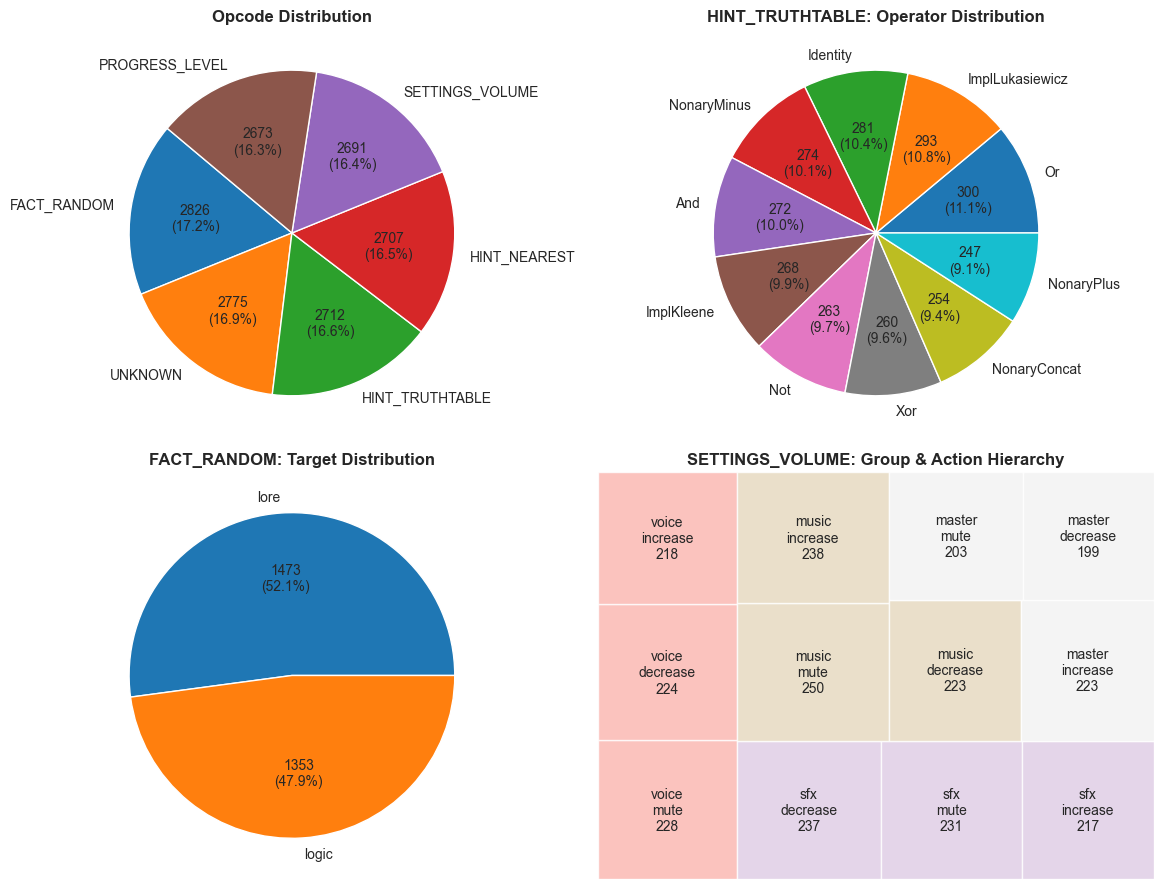

Total rows in dataset: 16384


In [4]:
import squarify # pip install squarify

def load_and_analyze(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)
            rows.append({
                "text": item["text"],
                "opcode": item["command"]["opcode"],
                "args": item["command"].get("recognizedArgs") or {}
            })
    df = pd.DataFrame(rows)

    # 1. Helper for labels: Count + Percentage
    def make_autopct(values):
        def my_autopct(pct):
            total = sum(values)
            val = int(round(pct * total / 100.0))
            return f'{val}\n({pct:.1f}%)'
        return my_autopct

    # 2. Setup Plot Grid (2x2)
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.flatten()

    # --- Opcode Distribution ---
    counts_op = df['opcode'].value_counts()
    axes[0].pie(counts_op, labels=counts_op.index, autopct=make_autopct(counts_op), startangle=140)
    axes[0].set_title("Opcode Distribution", fontweight='bold')

    # --- Operator Distribution (HINT_TRUTHTABLE) ---
    df_tt = df[df['opcode'] == 'HINT_TRUTHTABLE']
    counts_opr = df_tt['args'].apply(lambda x: x.get('operator', 'None')).value_counts()
    axes[1].pie(counts_opr, labels=counts_opr.index, autopct=make_autopct(counts_opr))
    axes[1].set_title("HINT_TRUTHTABLE: Operator Distribution", fontweight='bold')

    # --- Target Distribution (FACT_RANDOM) ---
    df_fact = df[df['opcode'] == 'FACT_RANDOM']
    counts_tgt = df_fact['args'].apply(lambda x: x.get('target', 'None')).value_counts()
    axes[2].pie(counts_tgt, labels=counts_tgt.index, autopct=make_autopct(counts_tgt))
    axes[2].set_title("FACT_RANDOM: Target Distribution", fontweight='bold')

    # --- Volume Treemap (SETTINGS_VOLUME) ---
    # Aggregate data for group + action
    df_vol = df[df['opcode'] == 'SETTINGS_VOLUME'].copy()
    df_vol['group'] = df_vol['args'].apply(lambda x: x.get('group', 'master'))
    df_vol['action'] = df_vol['args'].apply(lambda x: x.get('action', 'None'))

    vol_counts = df_vol.groupby(['group', 'action']).size().reset_index(name='counts')
    vol_counts = vol_counts.sort_values(by=['group', 'counts'], ascending=False)

    # Color mapping for groups
    unique_groups = vol_counts['group'].unique()
    colors = plt.cm.Pastel1(np.linspace(0, 1, len(unique_groups)))
    color_map = dict(zip(unique_groups, colors))

    labels = [f"{r['group']}\n{r['action']}\n{r['counts']}" for _, r in vol_counts.iterrows()]
    rect_colors = [color_map[g] for g in vol_counts['group']]

    plt.sca(axes[3]) # Set current axis for squarify
    squarify.plot(sizes=vol_counts['counts'], label=labels, color=rect_colors, alpha=0.8, ax=axes[3])
    axes[3].set_title("SETTINGS_VOLUME: Group & Action Hierarchy", fontweight='bold')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Total rows in dataset: {len(df)}")
    return df

df_full = load_and_analyze(DATASET_PATH)

## Подготовка данных
 
Разбиение датасета на обучающую, валидационную и тестовую выборку (в сочетании 0.64 : 0.16 : 0.2)

In [5]:
# Train/Val/Test Split (0.64 / 0.16 / 0.2)
train_df, test_df = train_test_split(df_full, test_size=0.2, random_state=42, stratify=df_full['opcode'])
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['opcode'])

Создание представления датасета

In [6]:
# Mappings using your provided enums
OPCODES = [e.value for e in CommandOpcode]
OPERATORS = [e.value for e in TritUnOp] + [e.value for e in TritBinOp] + [e.value for e in NonBinOp]
GROUPS = ["master", "music", "sfx", "voice"]
ACTIONS = ["increase", "decrease", "mute"]
TARGETS = ["logic", "lore"]

op2idx = {op: i for i, op in enumerate(OPCODES)}
def create_slot_maps(items):
    return {s: i + 1 for i, s in enumerate(items)}, {i + 1: s for i, s in enumerate(items)}

operator2idx, idx2operator = create_slot_maps(OPERATORS)
group2idx, idx2group = create_slot_maps(GROUPS)
action2idx, idx2action = create_slot_maps(ACTIONS)
target2idx, idx2target = create_slot_maps(TARGETS)

print(f"Opcodes: {OPCODES}")
print()
print(f"Operators: {OPERATORS}")
print(f"Operators mapping: {idx2operator} (0 if unknown)")

Opcodes: ['HINT_NEAREST', 'HINT_TRUTHTABLE', 'SETTINGS_VOLUME', 'PROGRESS_LEVEL', 'FACT_RANDOM', 'UNKNOWN']

Operators: ['Identity', 'Not', 'And', 'Or', 'Xor', 'ImplKleene', 'ImplLukasiewicz', 'NonaryPlus', 'NonaryMinus', 'NonaryConcat']
Operators mapping: {1: 'Identity', 2: 'Not', 3: 'And', 4: 'Or', 5: 'Xor', 6: 'ImplKleene', 7: 'ImplLukasiewicz', 8: 'NonaryPlus', 9: 'NonaryMinus', 10: 'NonaryConcat'} (0 if unknown)


In [7]:
class CommandDataset(Dataset):
    def __init__(self, dataframe, tokenizer):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        args = row['args']
        enc = self.tokenizer(row['text'], truncation=True, padding='max_length', max_length=MAX_LEN, return_tensors='pt')

        return {
            "input_ids": enc["input_ids"].flatten(),
            "attention_mask": enc["attention_mask"].flatten(),
            "labels": {
                "opcode": torch.tensor(op2idx.get(row['opcode'], op2idx["UNKNOWN"]), dtype=torch.long),
                "operator": torch.tensor(operator2idx.get(args.get("operator"), 0), dtype=torch.long),
                "group": torch.tensor(group2idx.get(args.get("group"), 0), dtype=torch.long),
                "action": torch.tensor(action2idx.get(args.get("action"), 0), dtype=torch.long),
                "target": torch.tensor(target2idx.get(args.get("target"), 0), dtype=torch.long),
                "balanced": torch.tensor(1 if args.get("balanced") is True else 2 if args.get("balanced") is False else 0, dtype=torch.long)
            }
        }


Дополнительные определения (классификатор и аналог `EarlyStopping`)

In [8]:
class CommandClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        h = self.bert.config.hidden_size
        self.heads = nn.ModuleDict({
            "opcode": nn.Linear(h, len(OPCODES)),
            "operator": nn.Linear(h, len(OPERATORS) + 1),
            "group": nn.Linear(h, len(GROUPS) + 1),
            "action": nn.Linear(h, len(ACTIONS) + 1),
            "target": nn.Linear(h, len(TARGETS) + 1),
            "balanced": nn.Linear(h, 3)
        })

    def forward(self, input_ids, attention_mask):
        pooled = self.bert(input_ids, attention_mask).last_hidden_state[:, 0, :]
        return {k: head(pooled) for k, head in self.heads.items()}

In [9]:
class EarlyStopping:
    def __init__(self, patience=3, path=WEIGHTS_PATH):
        self.patience = patience
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.path)
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience: self.early_stop = True

## Обучение

In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_loader = DataLoader(CommandDataset(train_df, tokenizer), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(CommandDataset(val_df, tokenizer), batch_size=BATCH_SIZE)

model = CommandClassifier().to(DEVICE)
optimizer = AdamW(model.parameters(), lr=5e-5)
criterion_main = nn.CrossEntropyLoss()
criterion_slot = nn.CrossEntropyLoss(ignore_index=0)
stopper = EarlyStopping(patience=5)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
        lbls = {k: v.to(DEVICE) for k, v in batch["labels"].items()}

        logits = model(ids, mask)
        loss = criterion_main(logits["opcode"], lbls["opcode"])
        for k in ["operator", "group", "action", "target", "balanced"]:
            if (lbls[k] != 0).any(): loss += criterion_slot(logits[k], lbls[k])

        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
            lbls = {k: v.to(DEVICE) for k, v in batch["labels"].items()}
            logits = model(ids, mask)
            loss = criterion_main(logits["opcode"], lbls["opcode"])
            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)
    print(f"Epoch {epoch+1} | Val Loss: {avg_val:.4f}")
    stopper(avg_val, model)
    if stopper.early_stop: break

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | Val Loss: 0.0507
Epoch 2 | Val Loss: 0.0151
Epoch 3 | Val Loss: 0.0082
Epoch 4 | Val Loss: 0.0048
Epoch 5 | Val Loss: 0.0031
Epoch 6 | Val Loss: 0.0023
Epoch 7 | Val Loss: 0.0015
Epoch 8 | Val Loss: 0.0013
Epoch 9 | Val Loss: 0.0009
Epoch 10 | Val Loss: 0.0007
Epoch 11 | Val Loss: 0.0006
Epoch 12 | Val Loss: 0.0005
Epoch 13 | Val Loss: 0.0004
Epoch 14 | Val Loss: 0.0004
Epoch 15 | Val Loss: 0.0004
Epoch 16 | Val Loss: 0.0003
Epoch 17 | Val Loss: 0.0001
Epoch 18 | Val Loss: 0.0001
Epoch 19 | Val Loss: 0.0001
Epoch 20 | Val Loss: 0.0002


## Тестирование

--- Opcode Performance ---
[PASS] F1-macro Opcode: 0.9985 >= 0.9
[PASS] Accuracy Opcode: 0.9985 >= 0.75
[PASS] F1-macro Operator (>1% freq): 1.0000 >= 0.75
[PASS] F1-macro balanced: 0.9971 >= 0.75
[PASS] F1-macro group: 0.9982 >= 0.75
[PASS] F1-macro action: 0.9981 >= 0.75
[PASS] F1-macro target: 1.0000 >= 0.75


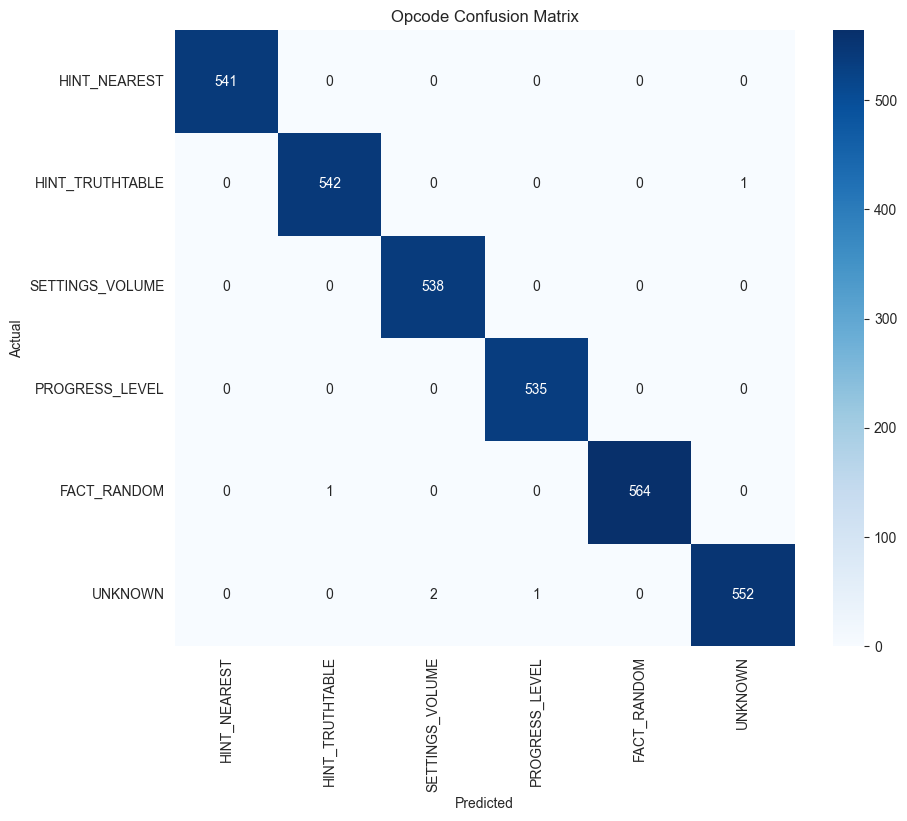

In [11]:
# Define the missing decoder for opcodes
idx2op = {v: k for k, v in op2idx.items()}

def soft_assert(name, val, threshold, context=""):
    if val < threshold:
        print(f"[\033[91mFAILED\033[0m] {name}: {val:.4f} < {threshold} {context}")
    else:
        print(f"[\033[92mPASS\033[0m] {name}: {val:.4f} >= {threshold}")

model.load_state_dict(torch.load(WEIGHTS_PATH))
model.eval()

# Storage for true/pred labels
results = {
    "opcode": {"true": [], "pred": []},
    "operator": {"true": [], "pred": []},
    "balanced": {"true": [], "pred": []},
    "group": {"true": [], "pred": []},
    "action": {"true": [], "pred": []},
    "target": {"true": [], "pred": []}
}

test_loader = DataLoader(CommandDataset(test_df, tokenizer), batch_size=BATCH_SIZE)

with torch.no_grad():
    for batch in test_loader:
        ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
        lbls = {k: v.cpu().numpy() for k, v in batch["labels"].items()}
        logits = model(ids, mask)
        preds = {k: torch.argmax(v, dim=1).cpu().numpy() for k, v in logits.items()}

        results["opcode"]["true"].extend(lbls["opcode"])
        results["opcode"]["pred"].extend(preds["opcode"])

        for i in range(len(preds["opcode"])):
            gold_op_idx = lbls["opcode"][i]
            pred_op_idx = preds["opcode"][i]
            gold_op_str = idx2op[gold_op_idx]

            # --- Condition: Only evaluate args if Opcode is correct ---
            if gold_op_idx == pred_op_idx:
                match gold_op_str:
                    case "HINT_TRUTHTABLE":
                        results["operator"]["true"].append(lbls["operator"][i])
                        results["operator"]["pred"].append(preds["operator"][i])
                        results["balanced"]["true"].append(lbls["balanced"][i])
                        results["balanced"]["pred"].append(preds["balanced"][i])
                    case "SETTINGS_VOLUME":
                        results["group"]["true"].append(lbls["group"][i])
                        results["group"]["pred"].append(preds["group"][i])
                        results["action"]["true"].append(lbls["action"][i])
                        results["action"]["pred"].append(preds["action"][i])
                    case "FACT_RANDOM":
                        results["target"]["true"].append(lbls["target"][i])
                        results["target"]["pred"].append(preds["target"][i])

# --- 1. Opcode Metrics ---
f1_op = f1_score(results["opcode"]["true"], results["opcode"]["pred"], average='macro')
acc_op = accuracy_score(results["opcode"]["true"], results["opcode"]["pred"])

print("--- Opcode Performance ---")
soft_assert("F1-macro Opcode", f1_op, 0.9)
soft_assert("Accuracy Opcode", acc_op, 0.75)

# --- 2. Operator Metric (>1% Filter) ---
if results["operator"]["true"]:
    y_true_opr = np.array(results["operator"]["true"])
    y_pred_opr = np.array(results["operator"]["pred"])

    unique, counts = np.unique(y_true_opr, return_counts=True)
    total_samples = len(y_true_opr)
    # Filter for indices that represent > 1% of the data
    valid_indices = unique[counts / total_samples > 0.01]

    # Filter true/pred lists to only include these high-frequency operators
    mask = np.isin(y_true_opr, valid_indices)
    f1_opr = f1_score(y_true_opr[mask], y_pred_opr[mask], average='macro')
    soft_assert("F1-macro Operator (>1% freq)", f1_opr, 0.75)

# --- 3. Other Slot Metrics ---
for slot in ["balanced", "group", "action", "target"]:
    if results[slot]["true"]:
        f1_s = f1_score(results[slot]["true"], results[slot]["pred"], average='macro')
        soft_assert(f"F1-macro {slot}", f1_s, 0.75)

# --- Heatmap ---
plt.figure(figsize=(10, 8))
cm = confusion_matrix(results["opcode"]["true"], results["opcode"]["pred"])
sns.heatmap(cm, annot=True, fmt='d', xticklabels=OPCODES, yticklabels=OPCODES, cmap="Blues")
plt.title("Opcode Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## Ручной вызов

Здесь вы можете попробовать классифицировать любую команду.

In [12]:
CONFIDENCE_THRESHOLD = 0.75
CONFIDENCE_THRESHOLD_OPERATOR = 0.6

def predict_command(text: str):
    enc = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LEN).to(DEVICE)
    model.eval()

    with torch.no_grad():
        res = model(enc["input_ids"], enc["attention_mask"])

        # 1. Opcode probabilities
        probs = torch.nn.functional.softmax(res["opcode"], dim=1)
        max_prob, op_idx = torch.max(probs, dim=1)
        op_str = idx2op[op_idx.item()]

        print(f"\n--- Opcode Confidence ---")
        for i, prob in enumerate(probs[0]):
            print(f"{idx2op[i]:16}: {prob.item():.2%}")
        print(f"{'Winner':16}: {op_str} ({max_prob.item():.2%})")

        if max_prob.item() < CONFIDENCE_THRESHOLD:
            print(f"\n[!] Low confidence. Overriding to UNKNOWN.")
            return UnknownCommand(opcode=CommandOpcode.UNKNOWN)

        # 2. Enhanced Helper for Slot Confidences
        def get_arg_with_conf(logits, mapping, category_name: str):
            # We ignore index 0 (None) and calculate softmax over the actual options
            valid_logits = logits[0, 1:]
            probs = torch.nn.functional.softmax(valid_logits, dim=0)

            winner_idx_in_slice = torch.argmax(probs).item()
            winner_prob = probs[winner_idx_in_slice].item()

            # The actual index for our mapping is offset by 1
            actual_idx = winner_idx_in_slice + 1
            val = mapping.get(actual_idx, "Unknown")

            print(f"\n--- {category_name} Confidence ---")
            for i, prob in enumerate(probs):
                name = mapping.get(i + 1, f"index_{i+1}")
                print(f"{name:16}: {prob.item():.2%}")
            print(f"{'Winner':16}: {val} ({winner_prob:.2%})")

            return val, winner_prob

        # 3. Match Logic with Argument Reporting
        match op_str:
            case "HINT_TRUTHTABLE":
                # Special handling for 'balanced' as it's not in a standard mapping dict
                bal_logits = res["balanced"][0, 1:]
                bal_probs = torch.nn.functional.softmax(bal_logits, dim=0)
                is_balanced = torch.argmax(bal_probs).item() == 0 # Index 0 of slice is True
                
                operator_winner, operator_prob = get_arg_with_conf(res["operator"], idx2operator, "Operator")

                print(f"\n--- Balanced Confidence ---")
                print(f"{'True':16}: {bal_probs[0].item():.2%}")
                print(f"{'False':16}: {bal_probs[1].item():.2%}")

                if operator_prob < CONFIDENCE_THRESHOLD_OPERATOR:
                    return UnknownCommand(opcode=CommandOpcode.UNKNOWN)
                
                return HintTruthtableCommand(
                    opcode=CommandOpcode.HINT_TRUTHTABLE,
                    recognizedArgs=HintTruthtableRecognizedArgs(
                        operator=operator_winner, balanced=is_balanced
                    )
                )

            case "SETTINGS_VOLUME":
                group_winner, group_prob = get_arg_with_conf(res["group"], idx2group, "Audio Group")
                action_winner, action_prob = get_arg_with_conf(res["action"], idx2action, "Audio Action")
                
                if group_prob < CONFIDENCE_THRESHOLD or action_prob < CONFIDENCE_THRESHOLD:
                    return UnknownCommand(opcode=CommandOpcode.UNKNOWN)
                
                return SettingsVolumeCommand(
                    opcode=CommandOpcode.SETTINGS_VOLUME,
                    recognizedArgs=SettingsVolumeRecognizedArgs(
                        group=group_winner, action=action_winner
                    )
                )

            case "FACT_RANDOM":
                target_winner, target_prob = get_arg_with_conf(res["target"], idx2target, "Fact Target")
                
                if target_prob < CONFIDENCE_THRESHOLD:
                    return UnknownCommand(opcode=CommandOpcode.UNKNOWN)
                
                return FactRandomCommand(
                    opcode=CommandOpcode.FACT_RANDOM,
                    recognizedArgs=FactRandomRecognizedArgs(
                        target=target_winner
                    )
                )

            case "PROGRESS_LEVEL":
                return ProgressLevelCommand(opcode=CommandOpcode.PROGRESS_LEVEL)

            case "HINT_NEAREST":
                return HintNearestCommand(opcode=CommandOpcode.HINT_NEAREST)

            case _:
                return UnknownCommand(opcode=CommandOpcode.UNKNOWN)

In [14]:
# --- EXECUTION ---
user_phrase = input("Enter command text for recognition check: ")

print("--- Command text ---")
print(user_phrase)
cmd = predict_command(clear_text(user_phrase))
print()
print("--- Final Classification Result ---")
print(cmd.model_dump_json(indent=4))

--- Command text ---
Подсказка по конъюнкции

--- Opcode Confidence ---
HINT_NEAREST    : 0.00%
HINT_TRUTHTABLE : 100.00%
SETTINGS_VOLUME : 0.00%
PROGRESS_LEVEL  : 0.00%
FACT_RANDOM     : 0.00%
UNKNOWN         : 0.00%
Winner          : HINT_TRUTHTABLE (100.00%)

--- Operator Confidence ---
Identity        : 0.00%
Not             : 0.00%
And             : 99.99%
Or              : 0.00%
Xor             : 0.00%
ImplKleene      : 0.00%
ImplLukasiewicz : 0.00%
NonaryPlus      : 0.00%
NonaryMinus     : 0.00%
NonaryConcat    : 0.00%
Winner          : And (99.99%)

--- Balanced Confidence ---
True            : 0.00%
False           : 100.00%

--- Final Classification Result ---
{
    "opcode": "HINT_TRUTHTABLE",
    "recognizedArgs": {
        "operator": "And",
        "balanced": false
    },
    "contextArgs": null
}
